In [18]:
!pip install openpyxl

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [20]:
uploaded = files.upload()

Saving Dataset_ML_Features.xlsx to Dataset_ML_Features (1).xlsx


In [21]:
df = pd.read_excel("Dataset_ML_Features.xlsx")

df.head()

,Year,Month,Day,Week,DayOfWeek,Season,Temperature,Wind,Solar,การผลิตประจำวัน(kWh)
0,2025,6,16,25,Monday,Rainy,28.6,8.7,17.72,5.1
1,2025,6,17,25,Tuesday,Rainy,30.0,8.3,21.78,6.6
2,2025,6,18,25,Wednesday,Rainy,29.9,6.7,21.77,13.2
3,2025,6,19,25,Thursday,Rainy,29.4,9.3,13.24,10.3
4,2025,6,20,25,Friday,Rainy,29.2,8.2,16.13,8.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  384 non-null    int64  
 1   Month                 384 non-null    int64  
 2   Day                   384 non-null    int64  
 3   Week                  384 non-null    int64  
 4   DayOfWeek             384 non-null    object 
 5   Season                384 non-null    object 
 6   Temperature           384 non-null    float64
 7   Wind                  384 non-null    float64
 8   Solar                 384 non-null    float64
 9   การผลิตประจำวัน(kWh)  384 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 30.1+ KB


In [23]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Week,0
DayOfWeek,0
Season,0
Temperature,0
Wind,0
Solar,0
การผลิตประจำวัน(kWh),0


In [24]:
le_day = LabelEncoder()
le_season = LabelEncoder()

df["DayOfWeek"] = le_day.fit_transform(df["DayOfWeek"])
df["Season"] = le_season.fit_transform(df["Season"])

In [25]:
X = df.drop(columns=["การผลิตประจำวัน(kWh)"])

y = df["การผลิตประจำวัน(kWh)"]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

In [27]:
model = GradientBoostingRegressor(

n_estimators=100,

learning_rate=0.1,

random_state=42

)

In [28]:
model.fit(X_train,y_train)

print("Train Success")

Train Success


In [29]:
y_pred = model.predict(X_test)

In [30]:
result = pd.DataFrame({

"Actual":y_test.values,

"Predicted":y_pred

})

result.head(20)

,Actual,Predicted
0,7.8,22.185817
1,32.0,20.099307
2,23.7,28.405640
3,23.2,24.891805
4,26.9,24.157080
5,19.9,20.596716
6,9.8,14.566750
7,26.6,18.986275
8,20.7,24.139908
9,23.3,17.721393


In [31]:
r2 = r2_score(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 =",r2)

print("RMSE =",rmse)

R2 = 0.5116060059180201
RMSE = 7.287578574622819


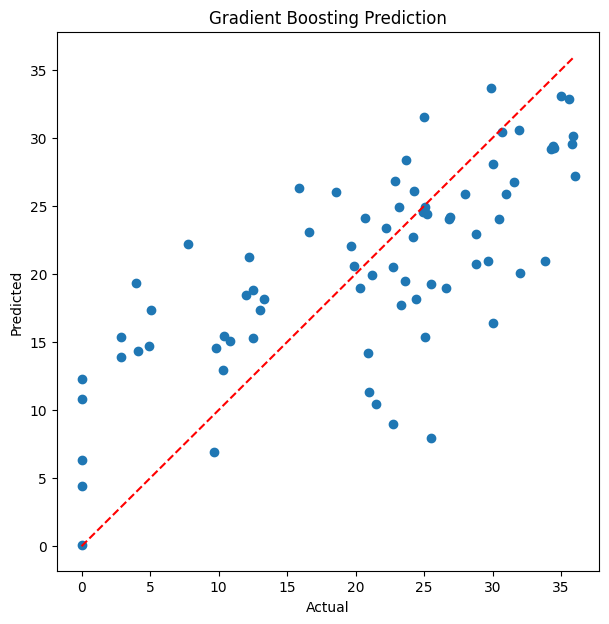

In [32]:
plt.figure(figsize=(7,7))

plt.scatter(y_test,y_pred)

plt.plot(

[y_test.min(),y_test.max()],

[y_test.min(),y_test.max()],

'r--'

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Gradient Boosting Prediction")

plt.show()

In [33]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":model.feature_importances_

})

importance.sort_values(

by="Importance",

ascending=False

)

,Feature,Importance
2,Day,0.275200
6,Temperature,0.254979
3,Week,0.192199
8,Solar,0.155128
1,Month,0.049802
7,Wind,0.048976
4,DayOfWeek,0.022284
0,Year,0.001432
5,Season,0.000000


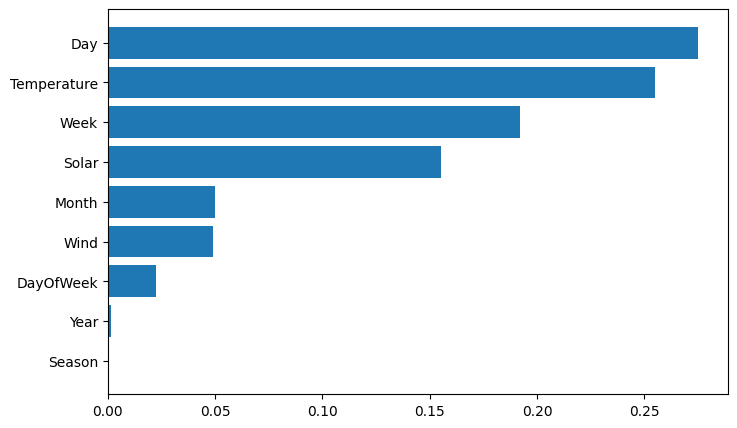

In [34]:
importance = importance.sort_values(

by="Importance",

ascending=True

)

plt.figure(figsize=(8,5))

plt.barh(

importance["Feature"],

importance["Importance"]

)

plt.show()

In [35]:
investment = 180000

electricity_price = 4.18

predicted_energy = df["การผลิตประจำวัน(kWh)"].mean()*365

saving = predicted_energy*electricity_price

payback = investment/saving

print("ผลิตไฟต่อปี =",predicted_energy)

print("ประหยัดต่อปี =",saving)

print("คืนทุน =",payback,"ปี")

ผลิตไฟต่อปี = 7419.005208333333
ประหยัดต่อปี = 31011.44177083333
คืนทุน = 5.80430930397091 ปี


In [36]:
print("========== Dashboard ==========")

print("Average Production =",round(df["การผลิตประจำวัน(kWh)"].mean(),2),"kWh/day")

print("R2 =",round(r2,3))

print("RMSE =",round(rmse,3))

print("Saving =",round(saving,2),"บาท/ปี")

print("Break-even =",round(payback,2),"ปี")

========== Dashboard ==========
Average Production = 20.33 kWh/day
R2 = 0.512
RMSE = 7.288
Saving = 31011.44 บาท/ปี
Break-even = 5.8 ปี
